# Tugas Praktikum 2: Praproses Data
## Dataset: House Prices - Advanced Regression Techniques (Kaggle)

**Mata Kuliah:** Praktikum Data Science / Machine Learning
**Tugas:** Praproses Data (Data Cleaning, Outlier Handling, Transformation, Dimensionality Reduction)

Notebook ini berisi seluruh tahapan praproses data pada dataset `train.csv` (1460 baris, 81 kolom) sesuai ketentuan praktikum:
1. Import & eksplorasi dataset
2. Pembersihan data (missing values)
3. Deteksi & penanganan outlier
4. Transformasi data (normalisasi & encoding)
5. Reduksi dimensi (korelasi & PCA)
6. Ringkasan dataset akhir


## 1. Unduh dan Import Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import missingno as msno

df = pd.read_csv('houseprices.csv')
display(df.shape)
display(df.head())


(1460, 81)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Dataset memiliki 1460 baris dan 81 kolom, terdiri dari kombinasi atribut numerik (integer/float) dan kategorikal (object). Kolom `SalePrice` adalah target/label harga rumah, sedangkan `Id` hanyalah pengenal baris dan tidak memiliki nilai informatif untuk analisis maupun model, sehingga akan dihapus.

In [2]:
df = df.drop(columns=['Id'])
df.shape

(1460, 80)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [4]:
numerical = df.select_dtypes(include=np.number).columns.tolist()
categorical = df.select_dtypes(include=str).columns.tolist()

display(df[numerical].describe())
display(df[categorical].describe())


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


## 2. Pembersihan Data

### Memeriksa Nilai yang Hilang

In [5]:
missing = df.isnull().sum()
percent = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase': percent})
missing_df = missing_df[missing_df['Jumlah Missing']>0].sort_values('Persentase', ascending=False)
missing_df


,Jumlah Missing,Persentase
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


<Figure size 1000x800 with 0 Axes>

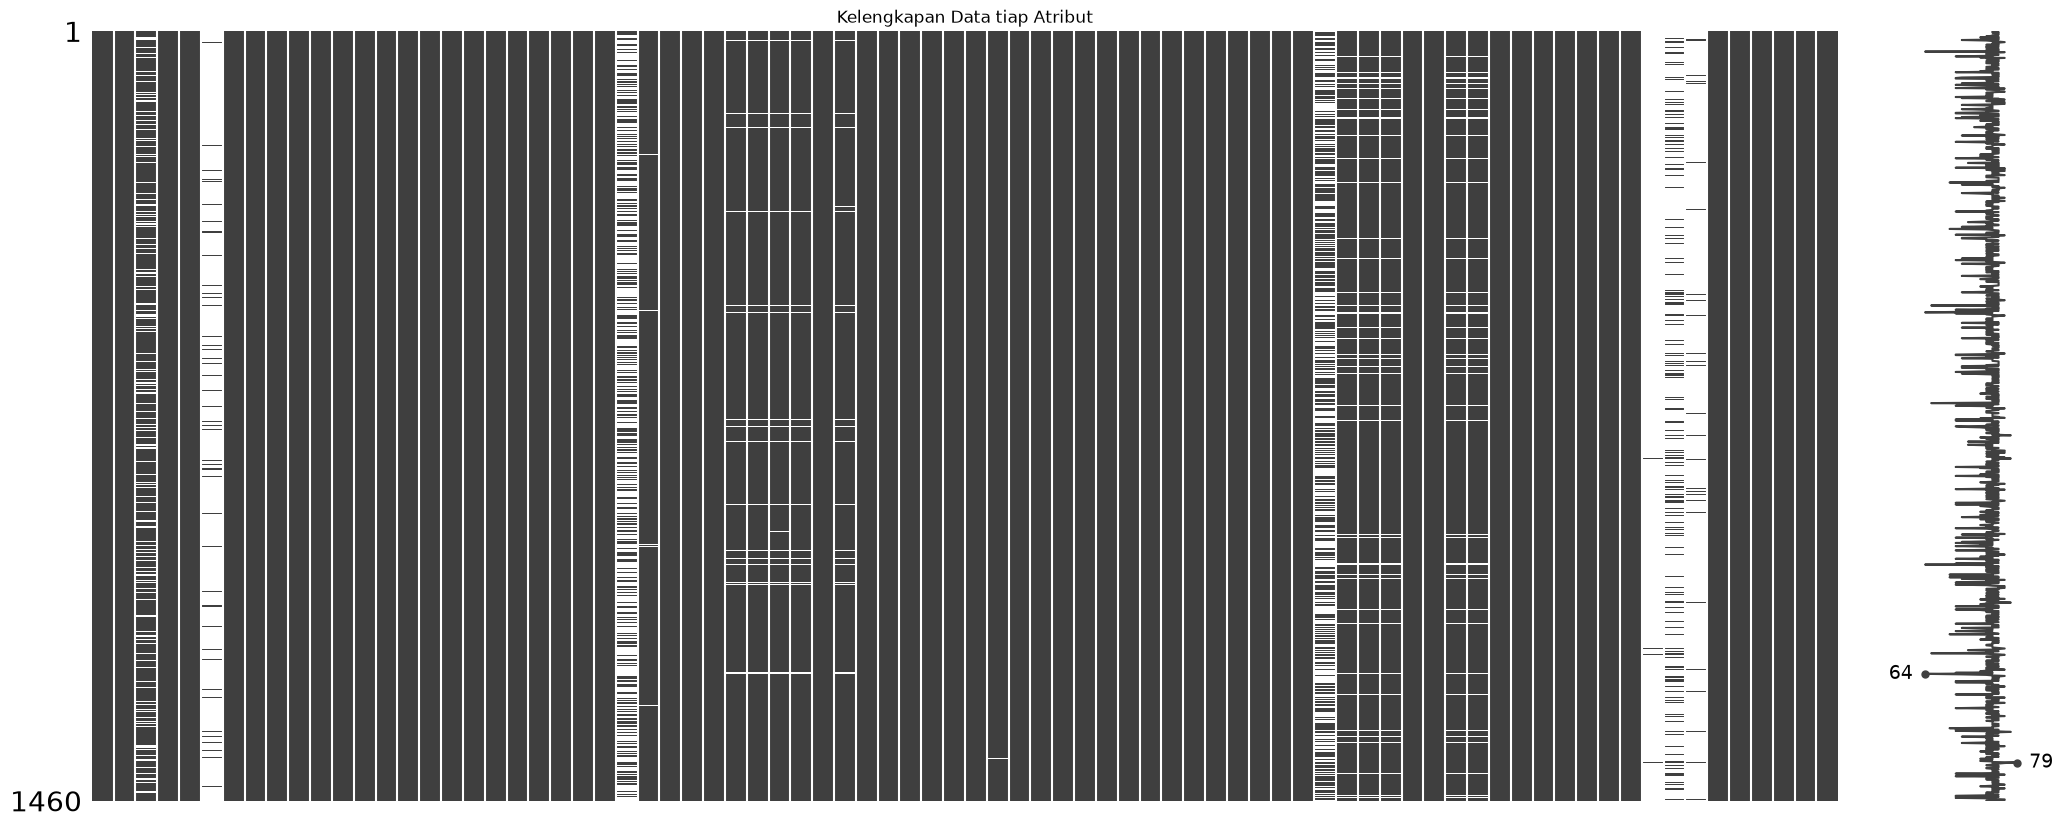

In [6]:
plt.figure(figsize=(10, 8))
msno.matrix(df)
plt.title('Kelengkapan Data tiap Atribut')
plt.savefig('missing.png', dpi=120)
plt.show()


Terdapat 19 atribut yang memiliki nilai hilang. Beberapa atribut seperti `PoolQC` (99.52%), `MiscFeature` (96.30%), `Alley` (93.77%), `Fence` (80.75%), dan `MasVnrType` (59.73%) memiliki proporsi missing di atas 50%, sehingga akan dihapus dari dataset karena informasinya terlalu minim untuk diimputasi.

### Menghapus Kolom dengan Missing Value > 50%

In [7]:
drop = missing_df[missing_df['Persentase'] > 50].index.tolist()
df = df.drop(columns=drop)

Strategi penanganan missing value ditentukan berdasarkan jenis atribut dan makna nilai `NA` berdasarkan data description dari Kaggle:

- Atribut kategorikal yang berkaitan dengan fitur rumah, seperti `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, dan `BsmtFinType2`, memiliki nilai `NA` yang menunjukkan bahwa fitur tersebut memang tidak dimiliki oleh rumah. Oleh karena itu, nilai `NA` diganti dengan label `"None"`.

* `GarageYrBlt`, yang merupakan atribut numerik untuk menunjukkan tahun pembangunan garasi, diisi dengan 0 karena `NA` menunjukkan bahwa rumah tersebut tidak memiliki garasi.

* `LotFrontage`, yang menunjukkan panjang sisi lot yang berbatasan dengan jalan, ditangani dengan mengisi nilai yang hilang menggunakan median berdasarkan `Neighborhood`.

* `MasVnrArea`, yang menunjukkan luas masonry veneer, diisi dengan nilai 0 karena `NA` menunjukkan bahwa rumah tidak memiliki veneer.

* `Electrical` hanya memiliki satu nilai yang hilang, sehingga nilai tersebut diisi menggunakan modus. Hal ini dilakukan karena jumlah missing value sangat kecil dan lebih baik jika diisi.


In [8]:
none_cols = ['FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']
for c in none_cols:
    if c in df.columns:
        df[c] = df[c].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

median = df.groupby('Neighborhood')['LotFrontage'].median()
df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(median))

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [9]:
df.shape


(1460, 75)

## 3. Deteksi dan Penanganan Outlier

Karena kolom numerik yang cukup banyak, maka akan digunakan Correlation Matrix untuk mencari atribut yang memiliki korelasi tertinggi dengan `SalePrice`

In [ ]:
plt.figure(figsize=(25, 20))
sb.heatmap(df[numerical].corr(), annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Korelasi antar Fitur")
plt.tight_layout()
plt.savefig('correlation.png', dpi=120)
plt.show()

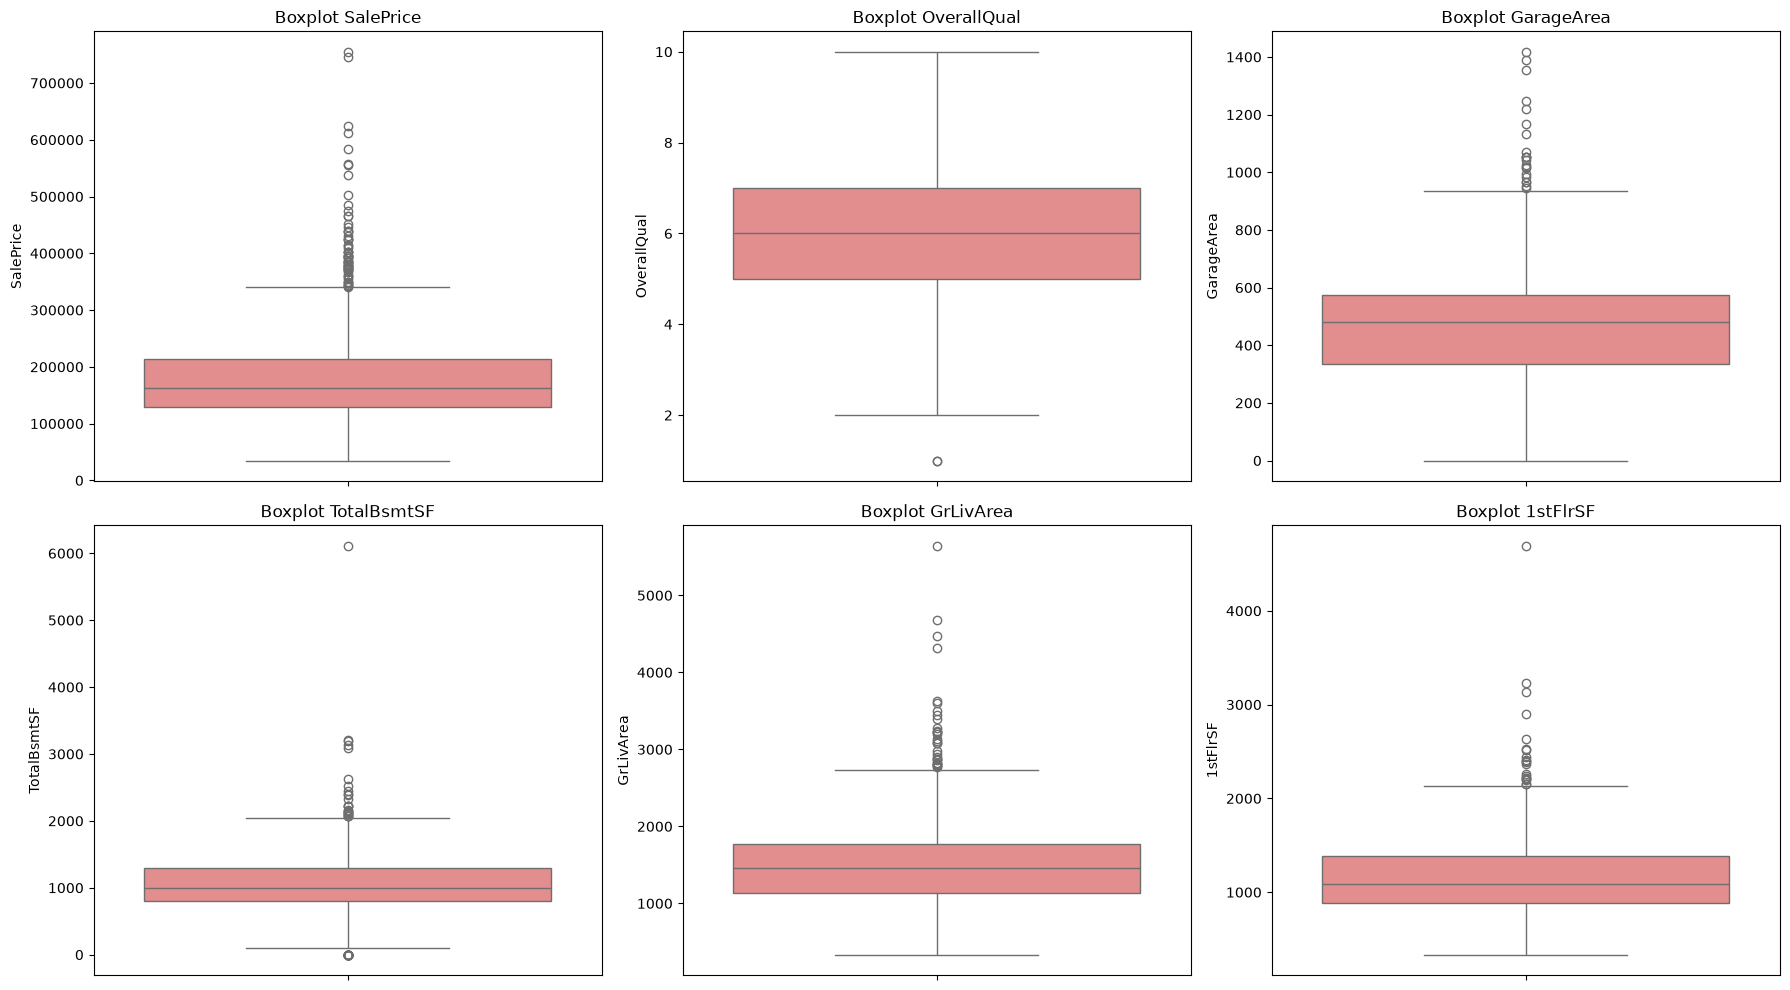

In [ ]:
top = ['SalePrice', 'OverallQual', 'GarageArea', 'TotalBsmtSF', 'GrLivArea', '1stFlrSF']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, top):
    sb.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot {col}')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=120)
plt.show()


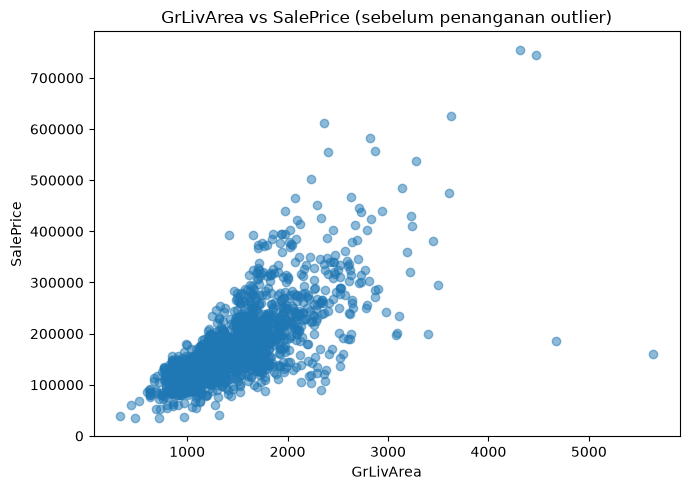

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice (sebelum penanganan outlier)')
plt.tight_layout()
plt.savefig('scatter.png', dpi=120)
plt.show()


Boxplot menunjukkan banyak outlier pada `1stFlrSF`, `GarageArea` dan `TotalBsmtSF` yang merupakan outlier alami (rumah besar/mahal yang memang ada di pasar). Namun pada scatter plot `GrLivArea` vs `SalePrice`, terdapat 2 titik dengan `GrLivArea` sangat besar (>4000 sqft) tetapi `SalePrice` justru rendah. 2 titik ini merupakan anomali, sehingga keduanya akan dihapus


In [ ]:
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))].reset_index(drop=True)

## 4. Transformasi Data

### Pemisahan Atribut Numerik dan Kategorikal

In [ ]:
numerical.remove("SalePrice")

### Standarisasi

Atribut numerik distandarisasi menggunakan StandarScaler agar memiliki mean = 0 dan standar deviasi = 1. Metode ini dipilih karena banyak atribut numerik pada dataset ini tidak berdistribusi normal secara ketat dan memiliki skala yang sangat berbeda (misal `LotArea` dalam ribuan, `OverallQual` dalam skala 1–10), sehingga standarisasi membantu menyetarakan skala antar-atribut untuk PCA dan model machine learning berikutnya.

In [ ]:
scaler = StandardScaler()
df_scaled_num = pd.DataFrame(scaler.fit_transform(df[numerical]), columns=numerical, index=df.index)
df_scaled_num.describe().T[['mean','std','min','max']].round(3).head(10)


,mean,std,min,max
MSSubClass,-0.0,1.0,-0.872,3.146
LotFrontage,-0.0,1.0,-2.283,11.323
LotArea,0.0,1.0,-0.929,20.778
OverallQual,-0.0,1.0,-3.702,2.839
OverallCond,0.0,1.0,-4.112,3.076
YearBuilt,0.0,1.0,-3.287,1.285
YearRemodAdd,0.0,1.0,-1.688,1.220
MasVnrArea,0.0,1.0,-0.571,8.365
BsmtFinSF1,0.0,1.0,-1.014,4.041
BsmtFinSF2,-0.0,1.0,-0.289,8.846


### Encoding Atribut Kategorikal (One-Hot Encoding)

In [ ]:
df_encoded_cat = pd.get_dummies(df[categorical], drop_first=True)
df_encoded_cat.head()


,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
df_transformed = pd.concat([df_scaled_num.reset_index(drop=True), df_encoded_cat.reset_index(drop=True), df["SalePrice"].reset_index(drop=True)], axis=1)
df_transformed.head()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,0.073426,-0.232605,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,False,False,False,True,False,False,False,True,False,208500
1,-0.871868,0.466313,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,False,False,False,True,False,False,False,True,False,181500
2,0.073426,-0.092822,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,False,False,False,True,False,False,False,True,False,223500
3,0.309749,-0.465578,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,False,False,False,True,False,False,False,False,False,140000
4,0.073426,0.652691,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,False,False,False,True,False,False,False,True,False,250000


## 5. Reduksi Dimensi

### Analisis Korelasi Antar Atribut Numerik

In [ ]:
corr = df[numerical].corr().abs()
high_corr_df = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index())
high_corr_df.columns = ['Atribut 1', 'Atribut 2', 'Korelasi']
high_corr_df = (high_corr_df[high_corr_df['Korelasi'] > 0.8].sort_values('Korelasi', ascending=False).reset_index(drop=True))
high_corr_df


,Atribut 1,Atribut 2,Korelasi
0,GarageCars,GarageArea,0.887304
1,GrLivArea,TotRmsAbvGrd,0.829498
2,TotalBsmtSF,1stFlrSF,0.803830


Beberapa pasangan atribut menunjukkan korelasi sangat tinggi (>0.8), misalnya `GarageCars` dengan `GarageArea` (jumlah mobil garasi vs luas garasi) dan `TotalBsmtSF` dengan `1stFlrSF` (luas basement vs luas lantai 1). Korelasi tinggi ini mengindikasikan redundansi informasi (multikolinearitas). Dari setiap pasangan, atribut kedua akan dibuang.

In [ ]:
redundant = sorted(set(high_corr_df['Atribut 2'].tolist()))
df_reduced_num = df_scaled_num.drop(columns=[c for c in redundant if c in df_scaled_num.columns])


### Principal Component Analysis (PCA)

PCA diterapkan pada seluruh atribut numerik yang telah distandarisasi (setelah reduksi korelasi) untuk mengurangi dimensi sambil mempertahankan sebagian besar varians data.

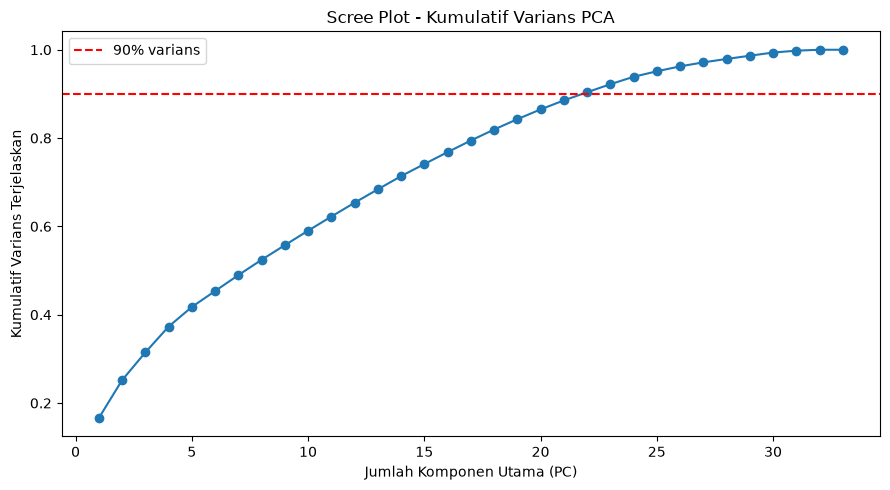

In [ ]:
pca_full = PCA()
pca_full.fit(df_reduced_num)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% varians')
plt.xlabel('Jumlah Komponen Utama (PC)')
plt.ylabel('Kumulatif Varians Terjelaskan')
plt.title('Scree Plot - Kumulatif Varians PCA')
plt.legend()
plt.tight_layout()
plt.savefig('fig_pca_scree.png', dpi=120)
plt.show()

n_components_90 = np.argmax(cum_var >= 0.90) + 1


In [ ]:
pca = PCA(n_components=n_components_90)
pca_result = pca.fit_transform(df_reduced_num)
pca_cols = [f'PC{i+1}' for i in range(n_components_90)]
df_pca = pd.DataFrame(pca_result, columns=pca_cols, index=df.index)
display(df_pca.shape)
display(df_pca.head())


Ukuran data numerik setelah PCA: (1458, 23)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
0,1.456468,0.267757,1.434357,-1.818849,0.407766,1.337467,0.163866,-0.575754,-0.348889,-0.440339,...,0.214423,-1.033193,0.014822,-1.116170,0.278962,-0.523258,-0.546434,-0.027981,-0.316117,-0.367296
1,0.045986,-1.179688,-1.266579,0.008743,-1.578186,-0.590450,-0.711503,3.524176,0.002312,0.787523,...,-0.765052,-1.342175,-0.013554,-0.335139,0.409742,0.191324,0.062346,-1.423548,0.213915,0.294807
2,1.686426,0.135922,1.269815,-1.194492,-0.134702,-0.179376,0.482333,-0.294270,-0.371968,-0.538012,...,0.183323,0.036694,-0.073591,0.033223,-0.593145,0.380536,-1.115000,0.253121,0.494698,-0.136418
3,-1.188875,0.817425,-1.450270,-0.464808,-0.152796,0.488137,0.492454,-1.634351,-2.330150,-1.261668,...,0.492050,0.921865,-0.148471,-1.718424,0.764876,-0.298166,-0.175680,-1.058410,-0.902411,0.291189
4,4.027243,0.863804,0.154991,-1.357074,0.091384,-0.507974,0.606108,0.361204,-0.748928,-0.521947,...,-0.034607,-0.260972,0.172829,0.585939,-1.295240,0.413324,0.008152,0.601576,-0.210040,-0.313817


 Dari puluhan atribut numerik awal, cukup sekitar beberapa puluh komponen utama untuk menjelaskan ≥90% varians data, menunjukkan bahwa banyak atribut numerik memiliki informasi yang tumpang tindih (redundan), sehingga PCA berhasil melakukan reduksi dimensi secara efektif.

## 6. Penyusunan Dataset Akhir

Dataset akhir yang disimpan menggabungkan:
- Atribut numerik yang sudah distandarisasi dan direduksi berdasarkan korelasi (`df_reduced_num`), dan
- Atribut kategorikal yang sudah di-one-hot-encode (`df_encoded_cat`), dan
- Kolom target `SalePrice` (harga rumah, tidak ditransformasi agar mudah diinterpretasi).

Komponen hasil PCA (`df_pca`) juga disimpan secara terpisah sebagai representasi data yang telah direduksi dimensinya, dapat digunakan sebagai alternatif input model.

In [ ]:
df_final = pd.concat(
    [df_reduced_num.reset_index(drop=True),
     df_encoded_cat.reset_index(drop=True),
     df["SalePrice"].reset_index(drop=True)],
    axis=1
)
print("Ukuran dataset akhir (numerik tereduksi + kategorikal encoded + target):", df_final.shape)
df_final.head()


Ukuran dataset akhir (numerik tereduksi + kategorikal encoded + target): (1458, 241)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,0.073426,-0.232605,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,False,False,False,True,False,False,False,True,False,208500
1,-0.871868,0.466313,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,False,False,False,True,False,False,False,True,False,181500
2,0.073426,-0.092822,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,False,False,False,True,False,False,False,True,False,223500
3,0.309749,-0.465578,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,False,False,False,True,False,False,False,False,False,140000
4,0.073426,0.652691,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,False,False,False,True,False,False,False,True,False,250000


In [ ]:
print(f"Ukuran awal dataset       : 1460 baris x 81 kolom")
print(f"Ukuran setelah cleaning   : {df.shape[0]} baris x {df.shape[1]} kolom "
f"(kolom Id & 5 kolom >50% missing dihapus, 2 baris outlier ekstrem dihapus)")
print(f"Jumlah atribut numerik    : {len(numerical)} -> setelah reduksi korelasi: {df_reduced_num.shape[1]}")
print(f"Jumlah atribut kategorikal: {len(categorical)} -> setelah one-hot encoding: {df_encoded_cat.shape[1]} kolom dummy")


Ukuran awal dataset       : 1460 baris x 81 kolom
Ukuran setelah cleaning   : 1458 baris x 75 kolom (kolom Id & 5 kolom >50% missing dihapus, 2 baris outlier ekstrem dihapus)
Jumlah atribut numerik    : 37 -> setelah reduksi korelasi: 34
Jumlah atribut kategorikal: 38 -> setelah one-hot encoding: 206 kolom dummy


In [ ]:
df_final.to_csv('dataset_final_praproses.csv', index=False)

Dataset akhir berhasil disimpan ke 'dataset_final_praproses.csv'


## Kesimpulan

Melalui rangkaian tahapan praproses data pada dataset House Prices, telah dilakukan:
1. **Pembersihan data**: menghapus kolom `Id` yang tidak informatif, menghapus 5 kolom dengan proporsi missing value >50% (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`), dan mengisi nilai hilang lainnya menggunakan strategi yang disesuaikan dengan makna semantik masing-masing atribut (label `"None"`, median per kelompok, atau modus).
2. **Penanganan outlier**: menghapus 2 baris anomali ekstrem pada `GrLivArea` vs `SalePrice`
3. **Transformasi data**: menstandarisasi seluruh atribut numerik dengan Z-score dan meng-encode seluruh atribut kategorikal dengan one-hot encoding.
4. **Reduksi dimensi**: mengidentifikasi dan membuang atribut numerik yang sangat berkorelasi (>0.8), serta menerapkan PCA untuk mereduksi dimensi data numerik sambil mempertahankan ≥90% varians.